In [ ]:
#  Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [19]:
house = fetch_california_housing(as_frame=True)
df = house.frame
df.rename(columns={"MedHouseVal": "PRICE"}, inplace=True)

In [20]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
#  Basic Info, missing values, duplicates
print(df.shape)
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
df.describe()


(20640, 9)
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64
Duplicates: 0


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


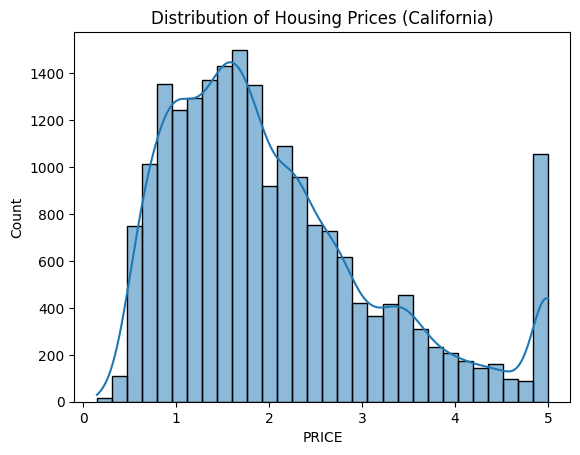

In [ ]:
#  Target exploration
sns.histplot(df["PRICE"], kde=True, bins=30)
plt.title("Distribution of Housing Prices (California)")
plt.show()


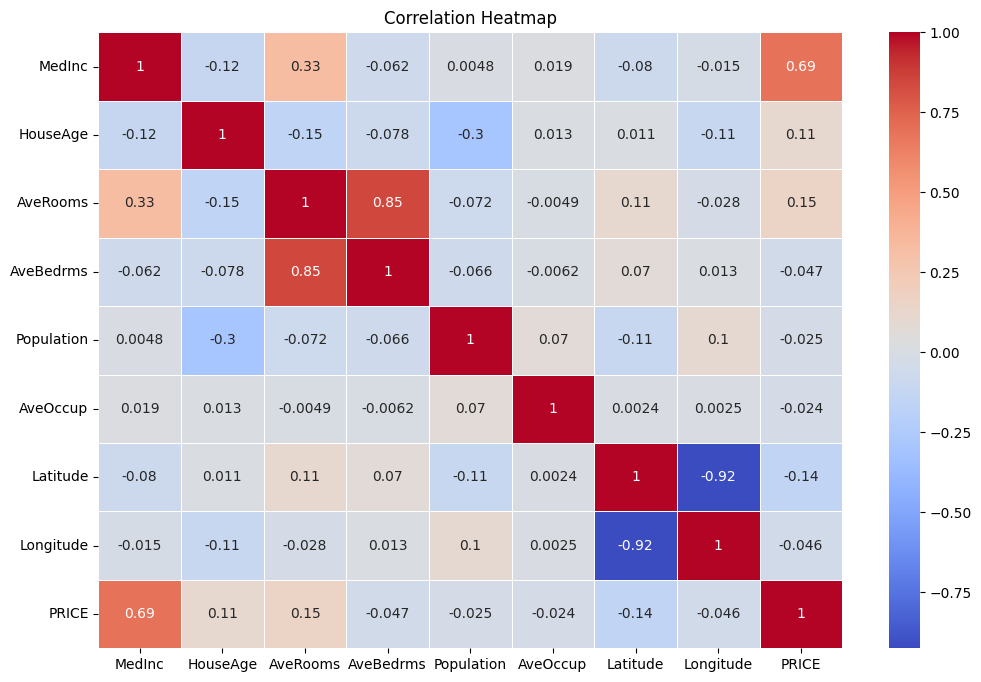

In [ ]:

#  Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", linewidths=0.5, annot=True)
plt.title("Correlation Heatmap")
plt.show()

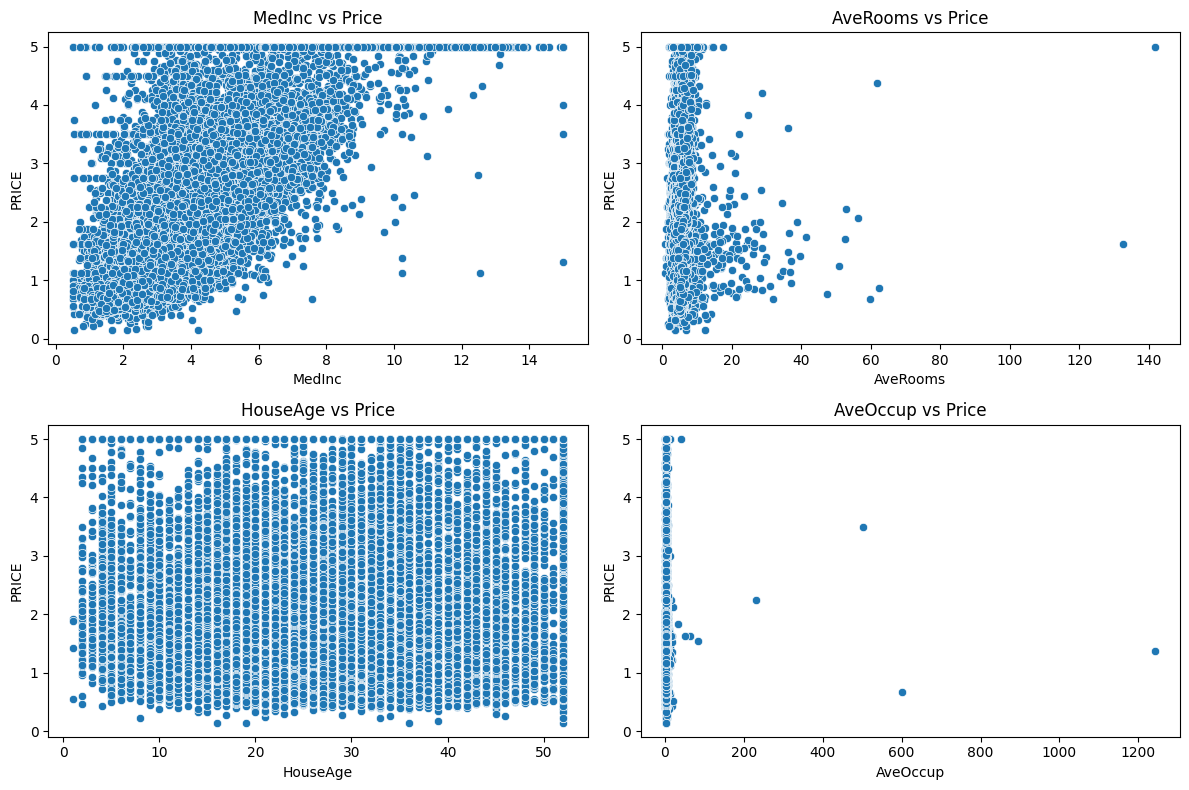

In [ ]:

#  Scatterplots with top features
corr = df.corr()["PRICE"].sort_values(ascending=False)
top_feats = corr.index[1:5]
plt.figure(figsize=(12,8))
for i, col in enumerate(top_feats, 1):
    plt.subplot(2,2,i)
    sns.scatterplot(x=df[col], y=df["PRICE"])
    plt.title(f"{col} vs Price")
plt.tight_layout()
plt.show()


In [ ]:
# Train-test split
X = df.drop("PRICE", axis=1)
y = df["PRICE"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Define models
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso()
}


In [ ]:
#  Train & evaluate
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})
res_df = pd.DataFrame(results).sort_values("RMSE")
print(res_df)


              Model      RMSE       MAE        R2
1             Ridge  0.745522  0.533204  0.575855
0  LinearRegression  0.745581  0.533200  0.575788
2             Lasso  0.968521  0.761578  0.284167


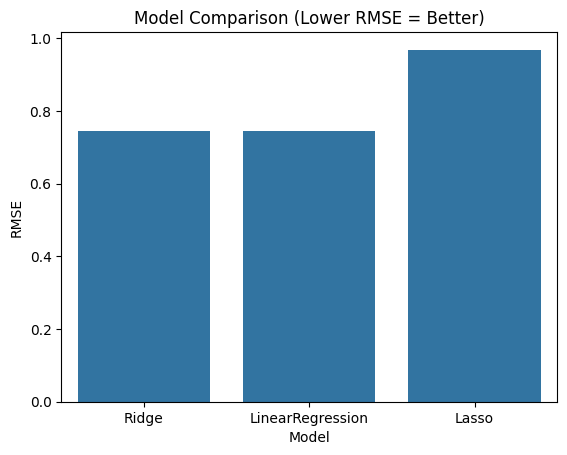

In [ ]:
#  Plot performance
sns.barplot(x="Model", y="RMSE", data=res_df)
plt.title("Model Comparison (Lower RMSE = Better)")
plt.show()



In [ ]:
#  Best model
best = res_df.iloc[0]
print(f"Best model: {best['Model']} (RMSE: {best['RMSE']:.2f}, MAE: {best['MAE']:.2f}, R2: {best['R2']:.2f})")

Best model: Ridge (RMSE: 0.75, MAE: 0.53, R2: 0.58)
